This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes are:
    - [4, 8]
    - [8, 16]
    - [8, 16, 32]
    - [16, 32, 64]
    - [16, 32, 64, 128]
    - [32, 64, 128, 256]
    - [32, 64, 128, 256, 512]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.cnn import CNN
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [7]:
# Define model configs

models_list = [
    {'hidden_ch': [4, 8]},
    {'hidden_ch': [8, 16]},
    {'hidden_ch': [8, 16, 32]},
    {'hidden_ch': [16, 32, 64]},
    {'hidden_ch': [16, 32, 64, 128]},
    {'hidden_ch': [32, 64, 128, 256]},
    {'hidden_ch': [32, 64, 128, 256, 512]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'cnn_8',
    'cnn_16',
    'cnn_32',
    'cnn_64',
    'cnn_128',
    'cnn_256',
    'cnn_512'
]

name_list = [
        'CNN_8',
        'CNN_16',
        'CNN_32',
        'CNN_64',
        'CNN_128',
        'CNN_256',
        'CNN_512'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'cnn' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.301904
Epoch 1/80, Step 2/47, Train Loss: 0.262784
Epoch 1/80, Step 3/47, Train Loss: 0.204897
Epoch 1/80, Step 4/47, Train Loss: 0.229857
Epoch 1/80, Step 5/47, Train Loss: 0.225675
Epoch 1/80, Step 6/47, Train Loss: 0.249781
Epoch 1/80, Step 7/47, Train Loss: 0.201339
Epoch 1/80, Step 8/47, Train Loss: 0.199043
Epoch 1/80, Step 9/47, Train Loss: 0.259569
Epoch 1/80, Step 10/47, Train Loss: 0.181863
Epoch 1/80, Step 11/47, Train Loss: 0.141625
Epoch 1/80, Step 12/47, Train Loss: 0.189473
Epoch 1/80, Step 13/47, Train Loss: 0.172580
Epoch 1/80, Step 14/47, Train Loss: 0.149477
Epoch 1/80, Step 15/47, Train Loss: 0.169900
Epoch 1/80, Step 16/47, Train Loss: 0.212592
Epoch 1/80, Step 17/47, Train Loss: 0.201024
Epoch 1/80, Step 18/47, Train Loss: 0.161244
Epoch 1/80, Step 19/47, Train Loss: 0.195220
Epoch 1/80, Step 20/47, Train Loss: 0.137521
Epoch 1/80, Step 21/47, Train Loss: 0.096072
Epoch 1/80, Step 22/47, Train Loss: 0.195551
Epoch 1/80, Step 23

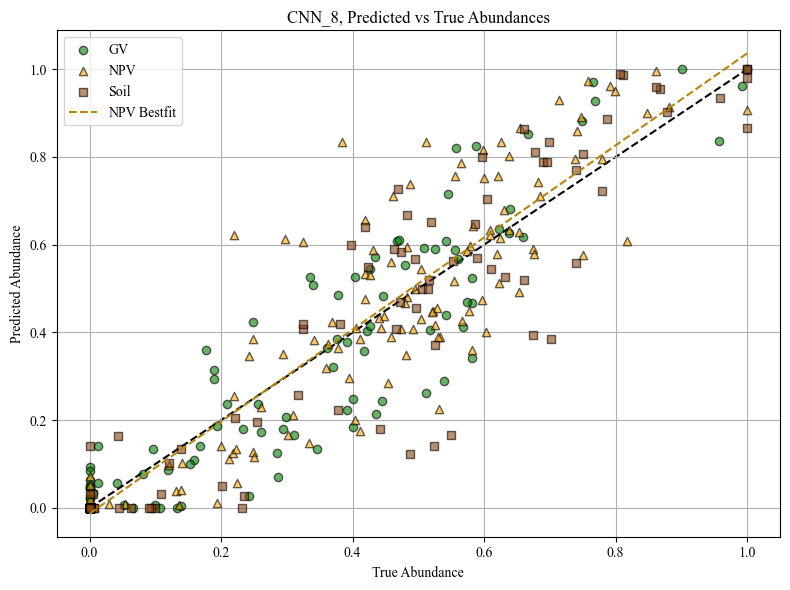

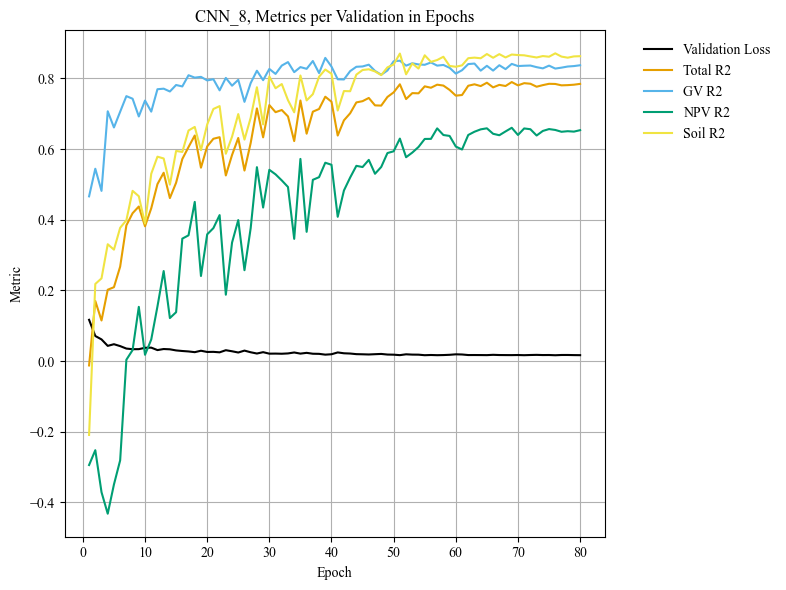

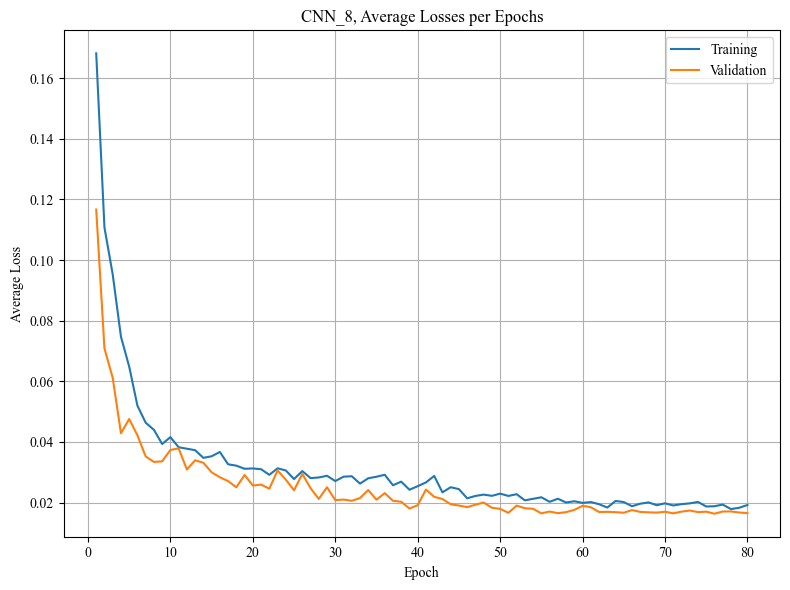

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.216521
Epoch 1/80, Step 2/47, Train Loss: 0.245599
Epoch 1/80, Step 3/47, Train Loss: 0.267987
Epoch 1/80, Step 4/47, Train Loss: 0.219245
Epoch 1/80, Step 5/47, Train Loss: 0.220893
Epoch 1/80, Step 6/47, Train Loss: 0.242405
Epoch 1/80, Step 7/47, Train Loss: 0.186353
Epoch 1/80, Step 8/47, Train Loss: 0.190329
Epoch 1/80, Step 9/47, Train Loss: 0.238365
Epoch 1/80, Step 10/47, Train Loss: 0.226911
Epoch 1/80, Step 11/47, Train Loss: 0.194809
Epoch 1/80, Step 12/47, Train Loss: 0.170311
Epoch 1/80, Step 13/47, Train Loss: 0.215441
Epoch 1/80, Step 14/47, Train Loss: 0.236806
Epoch 1/80, Step 15/47, Train Loss: 0.181633
Epoch 1/80, Step 16/47, Train Loss: 0.220643
Epoch 1/80, Step 17/47, Train Loss: 0.208645
Epoch 1/80, Step 18/47, Train Loss: 0.181112
Epoch 1/80, Step 19/47, Train Loss: 0.263754
Epoch 1/80, Step 20/47, Train Loss: 0.171286
Epoch 1/80, Step 21/47, Train Loss: 0.170341
Epoch 1/80, Step 22/47, Train Loss: 0.175890
Ep

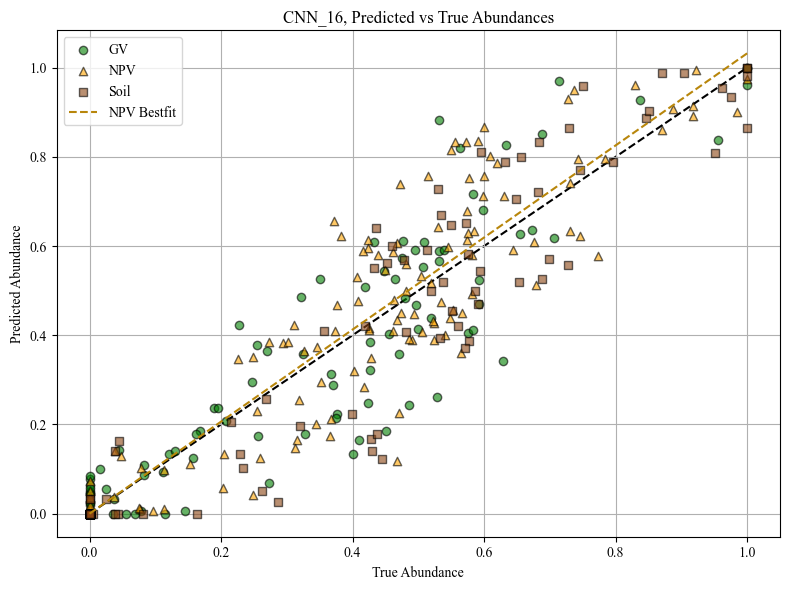

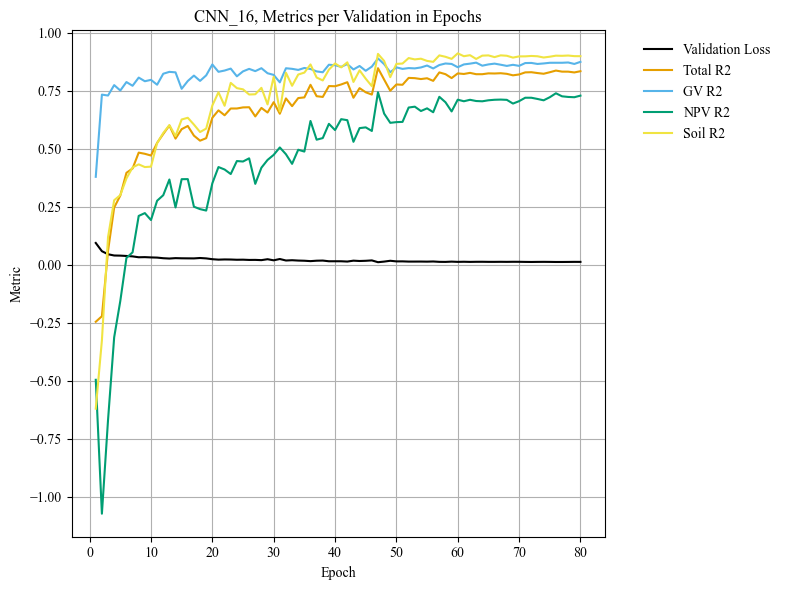

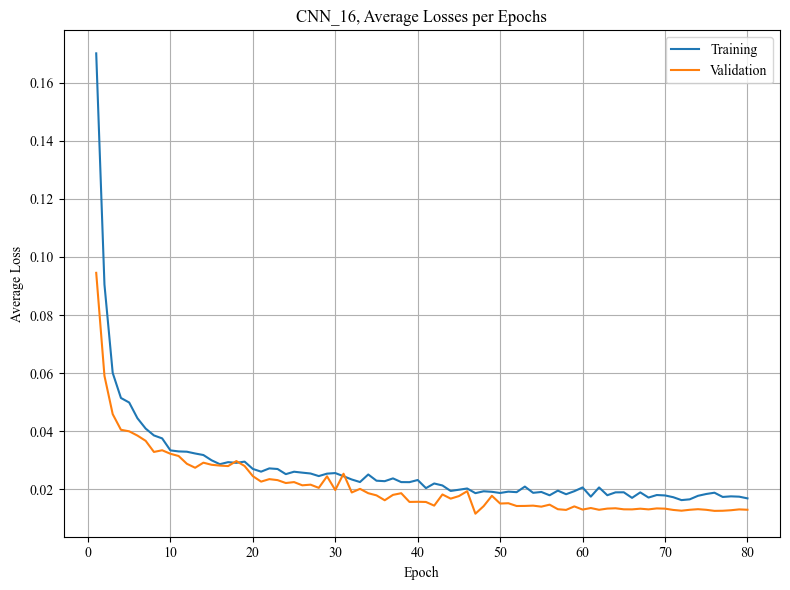

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.166089
Epoch 1/80, Step 2/47, Train Loss: 0.110756
Epoch 1/80, Step 3/47, Train Loss: 0.089502
Epoch 1/80, Step 4/47, Train Loss: 0.099685
Epoch 1/80, Step 5/47, Train Loss: 0.098963
Epoch 1/80, Step 6/47, Train Loss: 0.083606
Epoch 1/80, Step 7/47, Train Loss: 0.109605
Epoch 1/80, Step 8/47, Train Loss: 0.110717
Epoch 1/80, Step 9/47, Train Loss: 0.073491
Epoch 1/80, Step 10/47, Train Loss: 0.073296
Epoch 1/80, Step 11/47, Train Loss: 0.058943
Epoch 1/80, Step 12/47, Train Loss: 0.062214
Epoch 1/80, Step 13/47, Train Loss: 0.074755
Epoch 1/80, Step 14/47, Train Loss: 0.068423
Epoch 1/80, Step 15/47, Train Loss: 0.052512
Epoch 1/80, Step 16/47, Train Loss: 0.050881
Epoch 1/80, Step 17/47, Train Loss: 0.074652
Epoch 1/80, Step 18/47, Train Loss: 0.042023
Epoch 1/80, Step 19/47, Train Loss: 0.064113
Epoch 1/80, Step 20/47, Train Loss: 0.047334
Epoch 1/80, Step 21/47, Train Loss: 0.052182
Epoch 1/80, Step 22/47, Train Loss: 0.062579
Ep

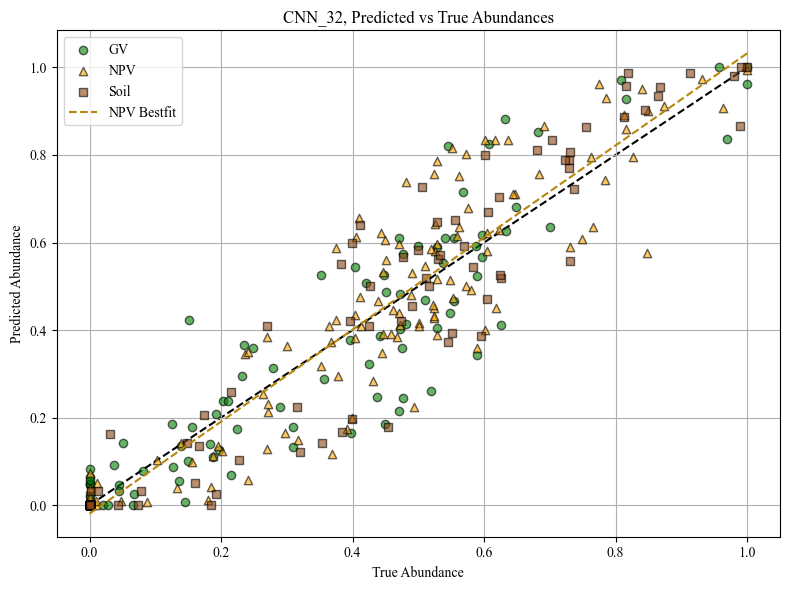

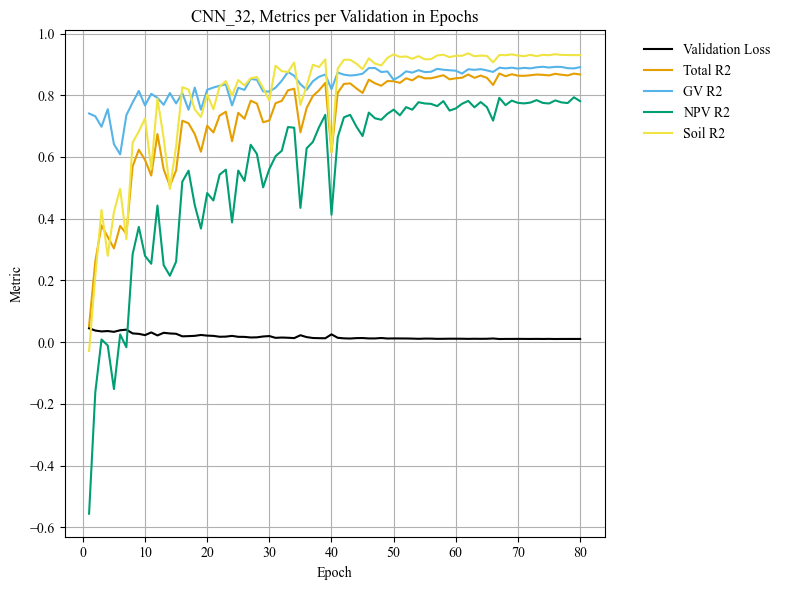

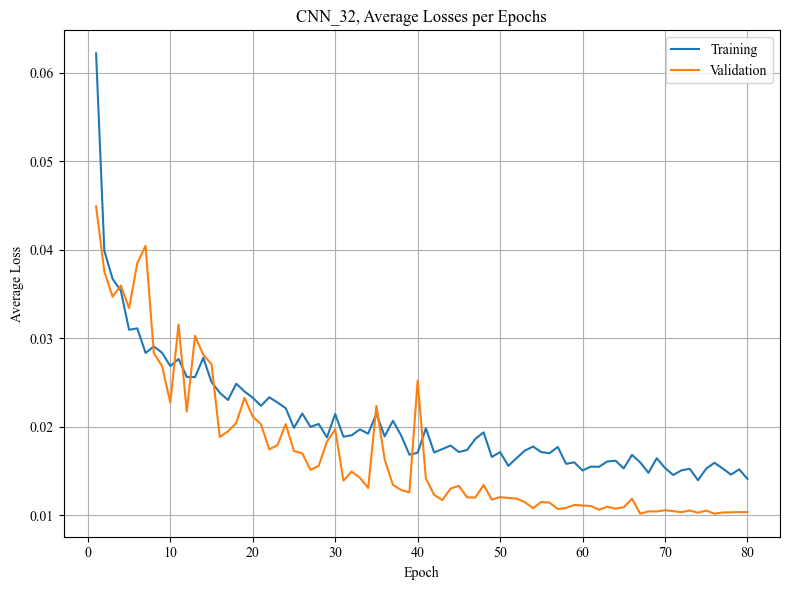

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.292574
Epoch 1/80, Step 2/47, Train Loss: 0.214446
Epoch 1/80, Step 3/47, Train Loss: 0.215828
Epoch 1/80, Step 4/47, Train Loss: 0.159105
Epoch 1/80, Step 5/47, Train Loss: 0.170877
Epoch 1/80, Step 6/47, Train Loss: 0.143634
Epoch 1/80, Step 7/47, Train Loss: 0.134961
Epoch 1/80, Step 8/47, Train Loss: 0.122836
Epoch 1/80, Step 9/47, Train Loss: 0.150528
Epoch 1/80, Step 10/47, Train Loss: 0.108357
Epoch 1/80, Step 11/47, Train Loss: 0.090982
Epoch 1/80, Step 12/47, Train Loss: 0.099889
Epoch 1/80, Step 13/47, Train Loss: 0.107978
Epoch 1/80, Step 14/47, Train Loss: 0.060160
Epoch 1/80, Step 15/47, Train Loss: 0.101885
Epoch 1/80, Step 16/47, Train Loss: 0.104352
Epoch 1/80, Step 17/47, Train Loss: 0.151237
Epoch 1/80, Step 18/47, Train Loss: 0.113466
Epoch 1/80, Step 19/47, Train Loss: 0.119423
Epoch 1/80, Step 20/47, Train Loss: 0.072317
Epoch 1/80, Step 21/47, Train Loss: 0.122512
Epoch 1/80, Step 22/47, Train Loss: 0.042925
Ep

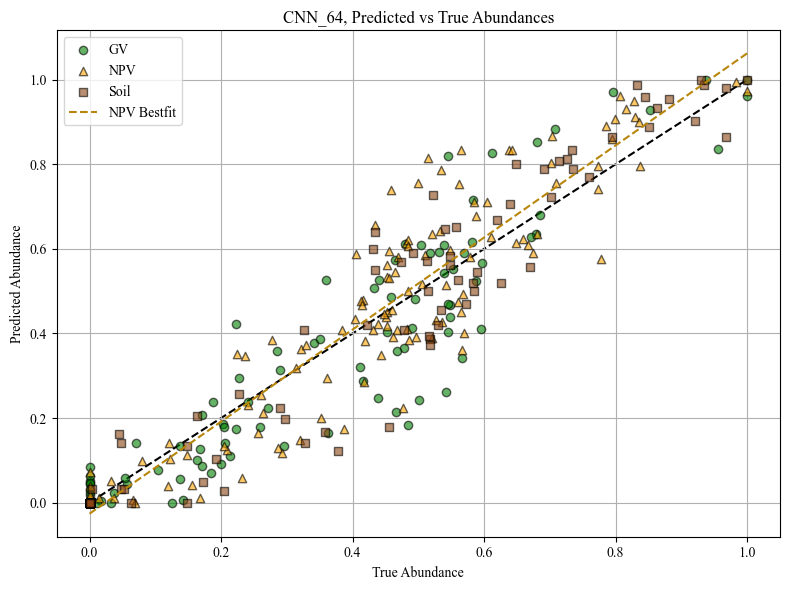

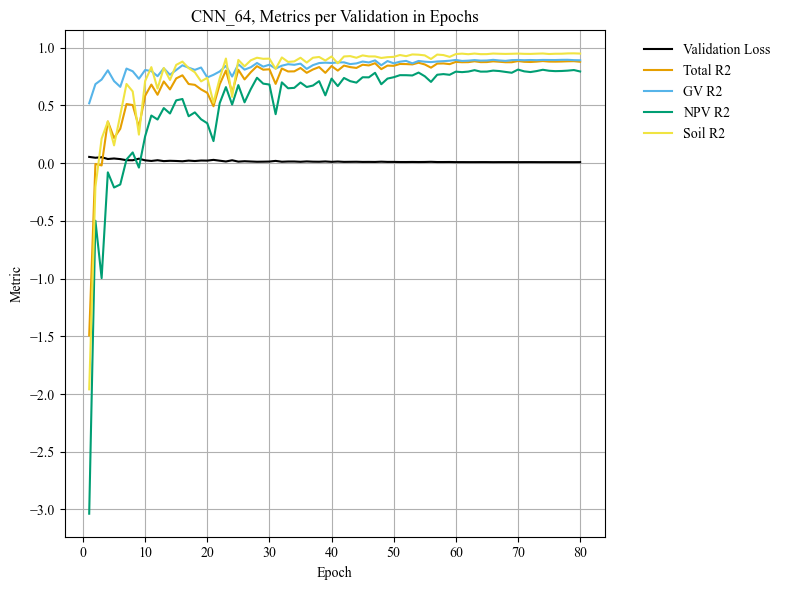

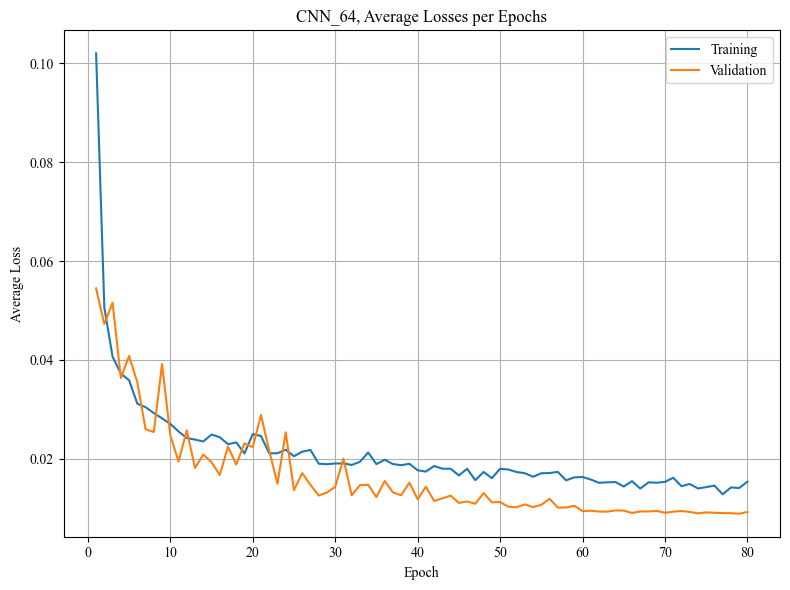

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.224334
Epoch 1/80, Step 2/47, Train Loss: 0.182609
Epoch 1/80, Step 3/47, Train Loss: 0.086563
Epoch 1/80, Step 4/47, Train Loss: 0.092323
Epoch 1/80, Step 5/47, Train Loss: 0.069618
Epoch 1/80, Step 6/47, Train Loss: 0.100817
Epoch 1/80, Step 7/47, Train Loss: 0.095730
Epoch 1/80, Step 8/47, Train Loss: 0.086399
Epoch 1/80, Step 9/47, Train Loss: 0.088234
Epoch 1/80, Step 10/47, Train Loss: 0.083241
Epoch 1/80, Step 11/47, Train Loss: 0.074707
Epoch 1/80, Step 12/47, Train Loss: 0.081616
Epoch 1/80, Step 13/47, Train Loss: 0.080731
Epoch 1/80, Step 14/47, Train Loss: 0.065038
Epoch 1/80, Step 15/47, Train Loss: 0.084175
Epoch 1/80, Step 16/47, Train Loss: 0.058790
Epoch 1/80, Step 17/47, Train Loss: 0.060770
Epoch 1/80, Step 18/47, Train Loss: 0.047651
Epoch 1/80, Step 19/47, Train Loss: 0.058904
Epoch 1/80, Step 20/47, Train Loss: 0.053539
Epoch 1/80, Step 21/47, Train Loss: 0.062922
Epoch 1/80, Step 22/47, Train Loss: 0.063010
Ep

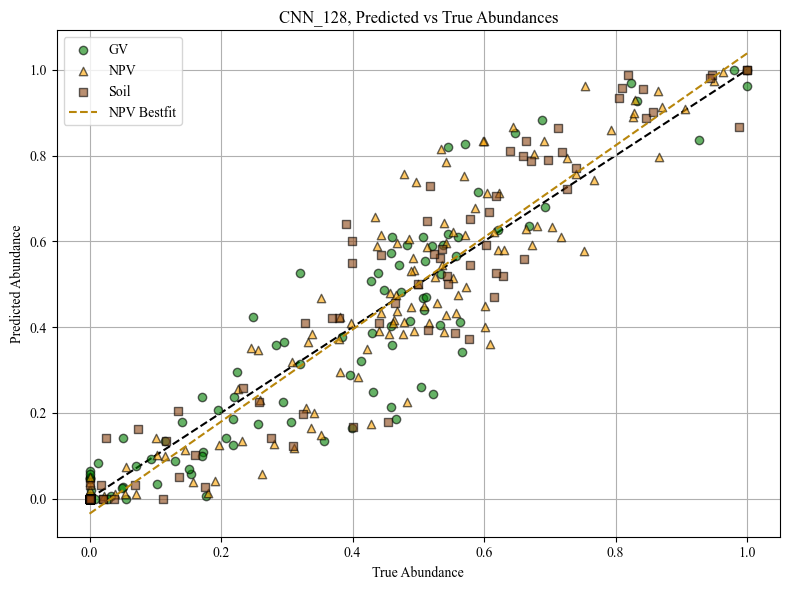

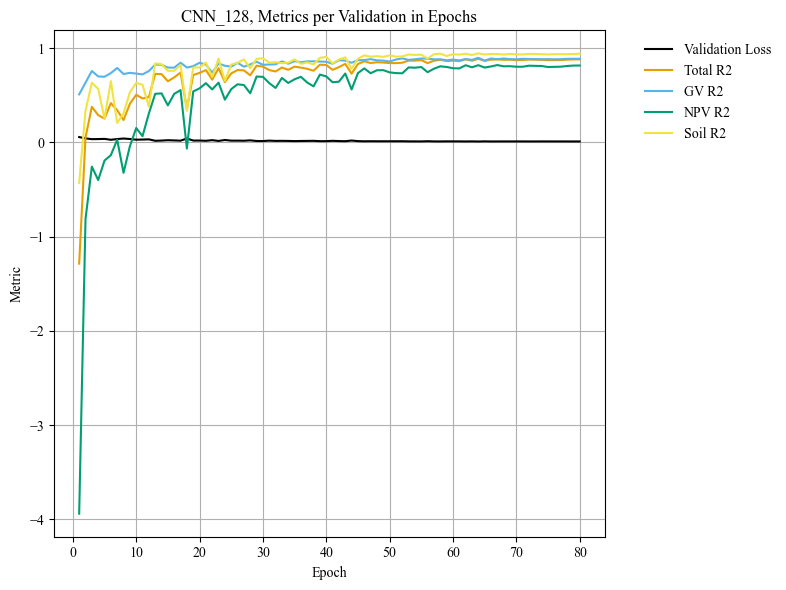

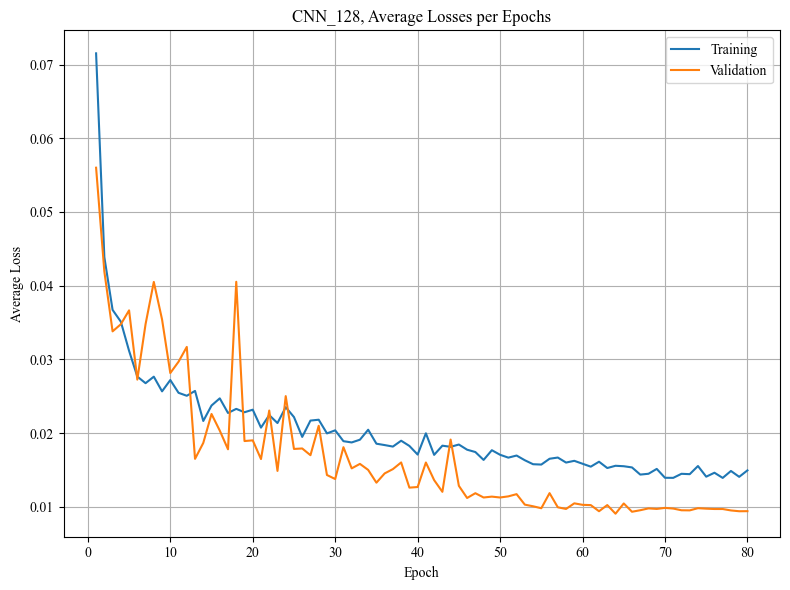

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.199995
Epoch 1/80, Step 2/47, Train Loss: 0.138500
Epoch 1/80, Step 3/47, Train Loss: 0.179793
Epoch 1/80, Step 4/47, Train Loss: 0.153596
Epoch 1/80, Step 5/47, Train Loss: 0.151652
Epoch 1/80, Step 6/47, Train Loss: 0.131734
Epoch 1/80, Step 7/47, Train Loss: 0.149170
Epoch 1/80, Step 8/47, Train Loss: 0.097729
Epoch 1/80, Step 9/47, Train Loss: 0.105650
Epoch 1/80, Step 10/47, Train Loss: 0.158134
Epoch 1/80, Step 11/47, Train Loss: 0.139802
Epoch 1/80, Step 12/47, Train Loss: 0.122737
Epoch 1/80, Step 13/47, Train Loss: 0.097598
Epoch 1/80, Step 14/47, Train Loss: 0.087712
Epoch 1/80, Step 15/47, Train Loss: 0.075023
Epoch 1/80, Step 16/47, Train Loss: 0.120961
Epoch 1/80, Step 17/47, Train Loss: 0.104585
Epoch 1/80, Step 18/47, Train Loss: 0.073894
Epoch 1/80, Step 19/47, Train Loss: 0.089447
Epoch 1/80, Step 20/47, Train Loss: 0.104570
Epoch 1/80, Step 21/47, Train Loss: 0.089239
Epoch 1/80, Step 22/47, Train Loss: 0.083284
Ep

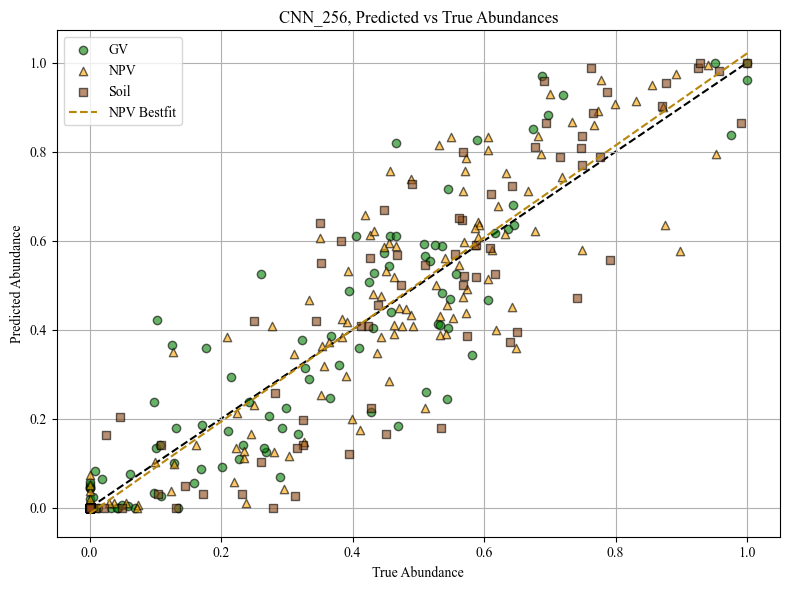

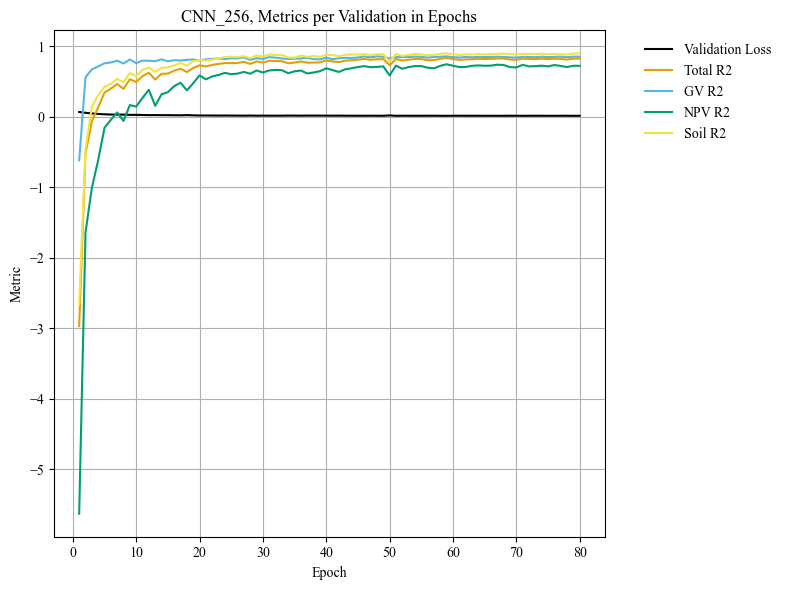

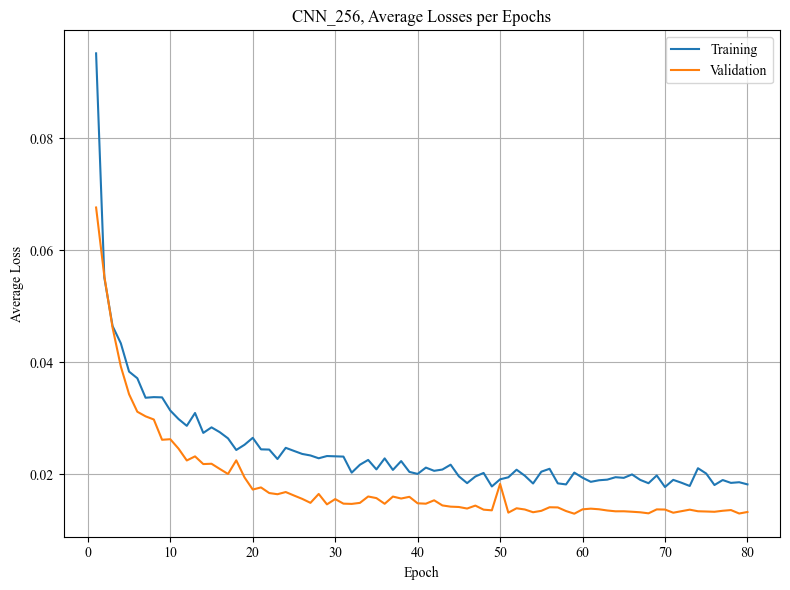

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.183209
Epoch 1/80, Step 2/47, Train Loss: 0.198161
Epoch 1/80, Step 3/47, Train Loss: 0.148324
Epoch 1/80, Step 4/47, Train Loss: 0.140579
Epoch 1/80, Step 5/47, Train Loss: 0.125529
Epoch 1/80, Step 6/47, Train Loss: 0.131913
Epoch 1/80, Step 7/47, Train Loss: 0.099801
Epoch 1/80, Step 8/47, Train Loss: 0.115837
Epoch 1/80, Step 9/47, Train Loss: 0.126602
Epoch 1/80, Step 10/47, Train Loss: 0.072767
Epoch 1/80, Step 11/47, Train Loss: 0.086868
Epoch 1/80, Step 12/47, Train Loss: 0.110345
Epoch 1/80, Step 13/47, Train Loss: 0.070713
Epoch 1/80, Step 14/47, Train Loss: 0.070801
Epoch 1/80, Step 15/47, Train Loss: 0.071079
Epoch 1/80, Step 16/47, Train Loss: 0.066244
Epoch 1/80, Step 17/47, Train Loss: 0.073996
Epoch 1/80, Step 18/47, Train Loss: 0.074484
Epoch 1/80, Step 19/47, Train Loss: 0.064497
Epoch 1/80, Step 20/47, Train Loss: 0.066348
Epoch 1/80, Step 21/47, Train Loss: 0.062148
Epoch 1/80, Step 22/47, Train Loss: 0.079695
Ep

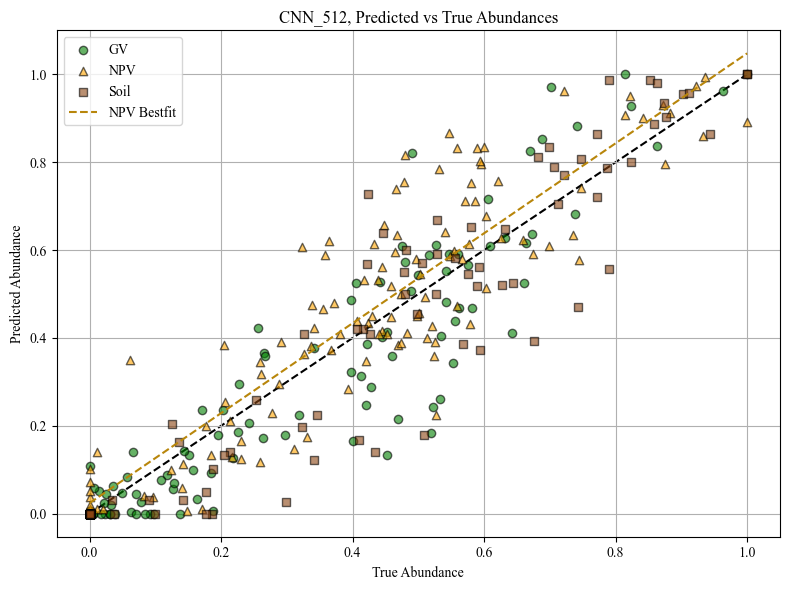

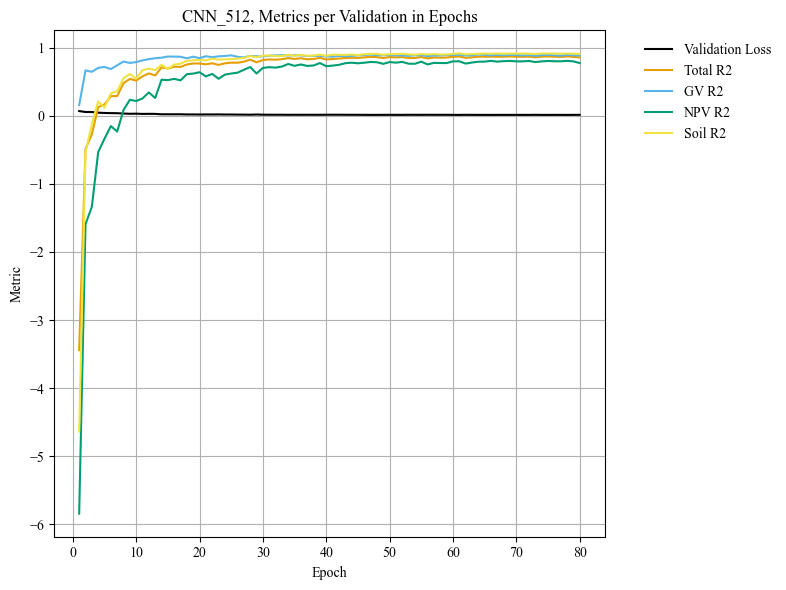

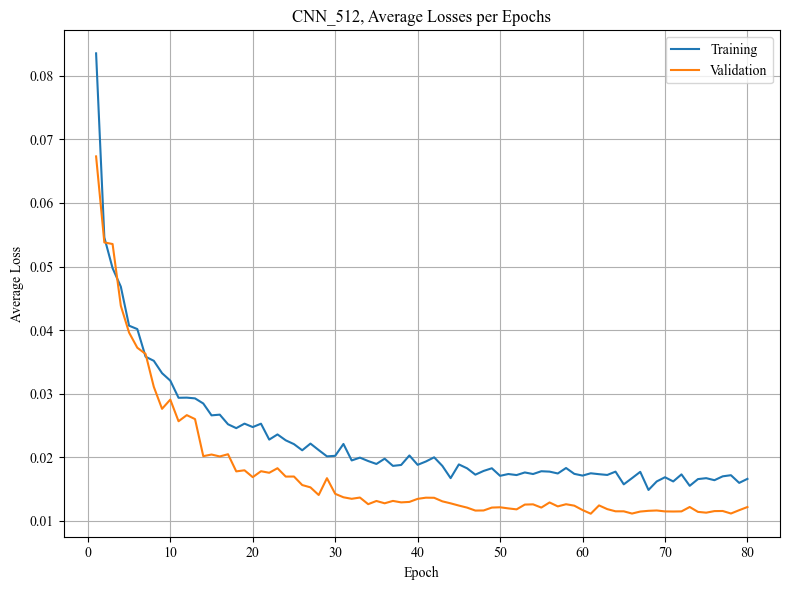

Testing complete


In [8]:
cnn_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1700], batch_size=32)
    model = CNN(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    cnn_dict[model_name] = model_dict

In [9]:
import pickle
with open('cnn_dict.pkl', 'wb') as fp:
    pickle.dump(cnn_dict, fp)

In [ ]:
# Best model
print(cnn_dict['CNN_64']['metrics_total'])

[[3.34490000e+04 1.31955800e+06 9.34445765e-03 8.65863979e-01
  8.76725614e-01 7.81589508e-01 9.39276636e-01 6.65946454e-02
  6.38780296e-02 8.67059156e-02 4.91999835e-02]]
